# Credit Risk Analytics — Retail Lending Portfolio
### Pacific Crest Bank (Hong Kong) — Group Risk & Analytics

**Author:** Credit Risk Analyst  ·  **Date:** June 2026

---

## 1. Business Context

Pacific Crest Bank is a multinational bank with a sizeable retail and SME
lending franchise booked through its Hong Kong entity. The Group Risk &
Analytics function is responsible for measuring and managing credit risk
across the consumer book — personal loans, credit cards, residential
mortgages and small-business facilities.

This study delivers an **end-to-end credit risk assessment** of a 12,000-facility
sample of the booked portfolio, aligned to the way Hong Kong banks underwrite:

* **Debt Servicing Ratio (DSR)** — the borrower's total monthly debt
  obligations divided by monthly income. The HKMA expects authorised
  institutions to apply DSR caps (typically 50%, with a stressed limit) and
  it is the single most important affordability metric locally.
* **Loan-to-Value (LTV)** — for secured lending, capped under HKMA
  countercyclical macroprudential measures.
* **TransUnion (TU) credit score** — the dominant consumer bureau score in HK.

### Objectives
1. Profile the portfolio and quantify the realised default rate.
2. Identify the drivers of default through exploratory analysis.
3. Build a **predictive default model (ML)** for ranking applications.
4. Build a **regulatory-style credit scorecard** (WOE / IV → points) that risk
   officers and front-line staff can interpret and that supports model
   governance.
5. Translate model output into **risk tiers, expected loss and lending
   policy recommendations**.

> *Data note:* the dataset is synthetic and generated for demonstration. It is
> engineered to reproduce economically sensible relationships (leverage,
> bureau history, affordability) and therefore behaves like a real book, but
> contains no real customer information.

In [1]:
# --- Environment ------------------------------------------------------- #
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve, average_precision_score,
)

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

OUT = Path("../outputs"); OUT.mkdir(exist_ok=True)
RNG = 42
print("Libraries loaded.")

Libraries loaded.


## 2. Data Loading

One row per booked facility. We load the raw extract exactly as it arrives
from the data warehouse — including the data-quality issues a real feed
contains — so the cleaning steps are explicit and auditable.

In [2]:
df = pd.read_csv("../data/credit_portfolio.csv")
print(f"Raw extract: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
df.head()

Raw extract: 12,025 rows  x  23 columns


,customer_id,age,gender,district,residential_status,employment_sector,employment_years,monthly_income_hkd,product_type,loan_amount_hkd,...,num_credit_cards,existing_debt_payment_hkd,new_payment_hkd,dsr,ltv,delinq_24m,months_since_delinq,credit_history_years,tu_credit_score,default_flag
0,HK1000000,60,F,Kowloon,Private Rental,Retail & F&B,6.500,"20,200.000",Credit Card,110000,...,1,2890,4400,0.361,NaN,1,19.000,23.500,646,1
1,HK1000001,55,F,New Territories,Private Rental,Professional Services,5.500,NaN,Credit Card,20000,...,2,1120,800,0.136,NaN,0,NaN,30.400,849,0
2,HK1000002,44,F,HK Island,Owner,Trade & Logistics,1.900,"27,700.000",Mortgage,2463000,...,3,9550,13810,0.843,0.455,1,13.000,13.300,604,0
3,HK1000003,38,M,New Territories,Owner,Construction,6.300,"19,000.000",Credit Card,43000,...,8,970,1720,0.142,NaN,0,NaN,11.100,775,0
4,HK1000004,53,F,Kowloon,Private Rental,Finance & Insurance,10.400,"24,500.000",Credit Card,130000,...,1,3140,5200,0.340,NaN,0,NaN,22.800,746,0


### 2.1 Data Dictionary

| Field | Description |
|---|---|
| `customer_id` | Unique facility / customer reference |
| `age`, `gender`, `district` | Applicant demographics (HK Island / Kowloon / NT) |
| `residential_status` | Owner / Private Rental / Public Housing / Living with Family |
| `employment_sector`, `employment_years` | Sector and tenure |
| `monthly_income_hkd` | Verified monthly income (HKD) |
| `product_type` | Personal Loan / Credit Card / Mortgage / SME Facility |
| `loan_amount_hkd`, `tenor_months`, `interest_rate_pct` | Facility terms |
| `num_existing_loans`, `num_credit_cards` | Bureau leverage counts |
| `existing_debt_payment_hkd`, `new_payment_hkd` | Monthly obligations (HKD) |
| `dsr` | **Debt Servicing Ratio** = total monthly debt / monthly income |
| `ltv` | **Loan-to-Value** (secured products only) |
| `delinq_24m`, `months_since_delinq` | Recent delinquency behaviour |
| `credit_history_years`, `tu_credit_score` | Bureau depth and TU score (300–850) |
| `default_flag` | **Target** — 1 if 90+ DPD within 12 months, else 0 |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12025 entries, 0 to 12024
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                12025 non-null  object 
 1   age                        12025 non-null  int64  
 2   gender                     12025 non-null  object 
 3   district                   12025 non-null  object 
 4   residential_status         12025 non-null  object 
 5   employment_sector          12025 non-null  object 
 6   employment_years           11905 non-null  float64
 7   monthly_income_hkd         11845 non-null  float64
 8   product_type               12025 non-null  object 
 9   loan_amount_hkd            12025 non-null  int64  
 10  tenor_months               12025 non-null  int64  
 11  interest_rate_pct          12025 non-null  float64
 12  num_existing_loans         12025 non-null  int64  
 13  num_credit_cards           12025 non-null  int

## 3. Data Quality & Cleaning

Checks performed: duplicate facilities, implausible values, missing data.
Every treatment below is logged so the pipeline is reproducible and auditable
— a model-governance requirement.

In [4]:
# Duplicates
n_dupes = df.duplicated().sum()

# Implausible ages (underwriting range is 18-70)
bad_age = df[(df["age"] < 18) | (df["age"] > 70)]

# Missingness
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Exact duplicate rows .......... {n_dupes}")
print(f"Implausible ages (<18 or >70).. {len(bad_age)}")
print("\nMissing values by column:")
print(missing.to_string())

Exact duplicate rows .......... 25
Implausible ages (<18 or >70).. 8

Missing values by column:
months_since_delinq    8501
ltv                    7720
monthly_income_hkd      180
employment_years        120


In [5]:
clean = df.copy()

# 1) Drop exact duplicates
clean = clean.drop_duplicates().reset_index(drop=True)

# 2) Treat implausible ages as missing, then impute with median
clean.loc[(clean["age"] < 18) | (clean["age"] > 70), "age"] = np.nan
clean["age"] = clean["age"].fillna(clean["age"].median()).astype(int)

# 3) Impute income by product-type median (income scales with product)
clean["monthly_income_hkd"] = clean.groupby("product_type")["monthly_income_hkd"] \
    .transform(lambda s: s.fillna(s.median()))

# 4) Impute employment tenure with overall median
clean["employment_years"] = clean["employment_years"] \
    .fillna(clean["employment_years"].median())

# 5) ltv is structurally missing for unsecured products -> keep NaN, flag it
clean["is_secured"] = clean["ltv"].notna().astype(int)

# 6) months_since_delinq missing = never delinquent -> encode as 99 sentinel
clean["months_since_delinq"] = clean["months_since_delinq"].fillna(99)

print(f"Clean dataset: {clean.shape[0]:,} rows")
print(f"Remaining missing (excl. structural ltv): "
      f"{clean.drop(columns='ltv').isna().sum().sum()}")

Clean dataset: 12,000 rows
Remaining missing (excl. structural ltv): 0


## 4. Exploratory Data Analysis

We move from the headline default rate to the segment and driver level,
building the intuition the scorecard will later formalise.

Portfolio 12-month default rate: 13.59%


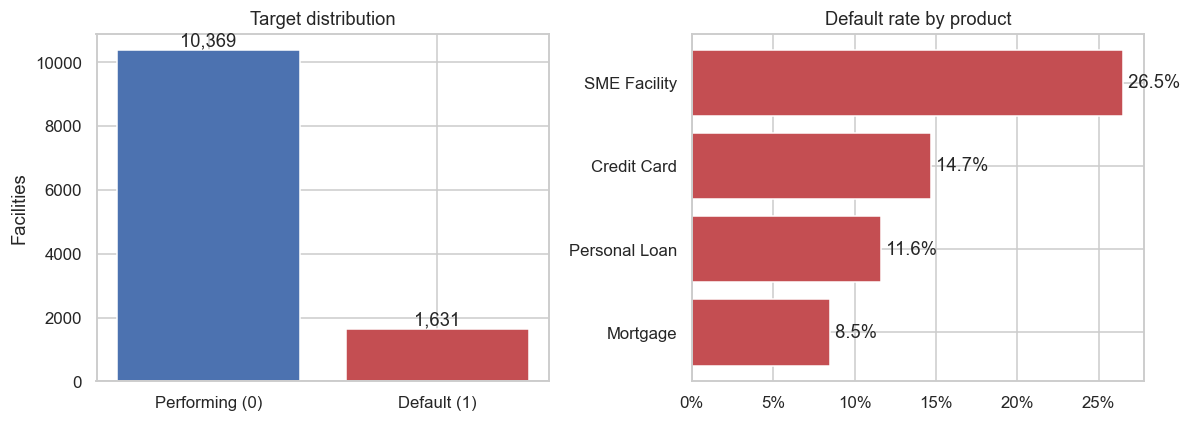

In [6]:
overall_dr = clean["default_flag"].mean()
print(f"Portfolio 12-month default rate: {overall_dr:.2%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = clean["default_flag"].value_counts().sort_index()
ax[0].bar(["Performing (0)", "Default (1)"], counts.values,
          color=["#4C72B0", "#C44E52"])
ax[0].set_title("Target distribution")
ax[0].set_ylabel("Facilities")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

dr_prod = clean.groupby("product_type")["default_flag"].mean().sort_values()
ax[1].barh(dr_prod.index, dr_prod.values, color="#C44E52")
ax[1].set_title("Default rate by product")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for i, v in enumerate(dr_prod.values):
    ax[1].text(v, i, f" {v:.1%}", va="center")
plt.tight_layout()
plt.savefig(OUT / "01_target_and_product.png", bbox_inches="tight")
plt.show()

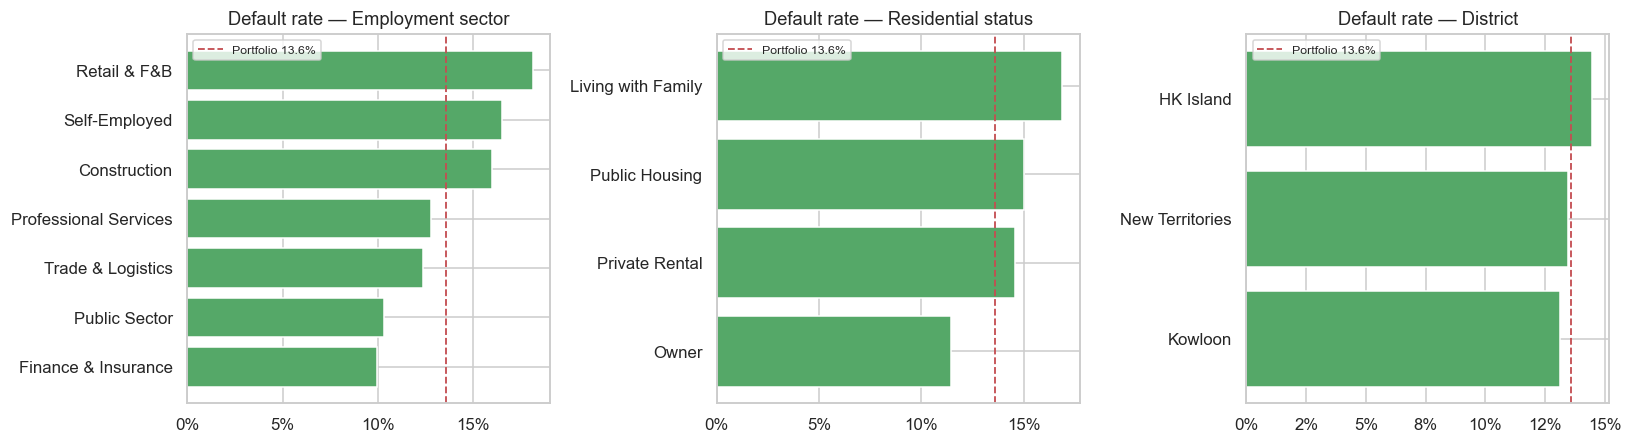

In [7]:
# Default rate across categorical segments
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(
    axes,
    ["employment_sector", "residential_status", "district"],
    ["Employment sector", "Residential status", "District"],
):
    dr = clean.groupby(col)["default_flag"].mean().sort_values()
    ax.barh(dr.index, dr.values, color="#55A868")
    ax.axvline(overall_dr, color="#C44E52", ls="--", lw=1.2,
               label=f"Portfolio {overall_dr:.1%}")
    ax.set_title(f"Default rate — {title}")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "02_segment_default_rates.png", bbox_inches="tight")
plt.show()

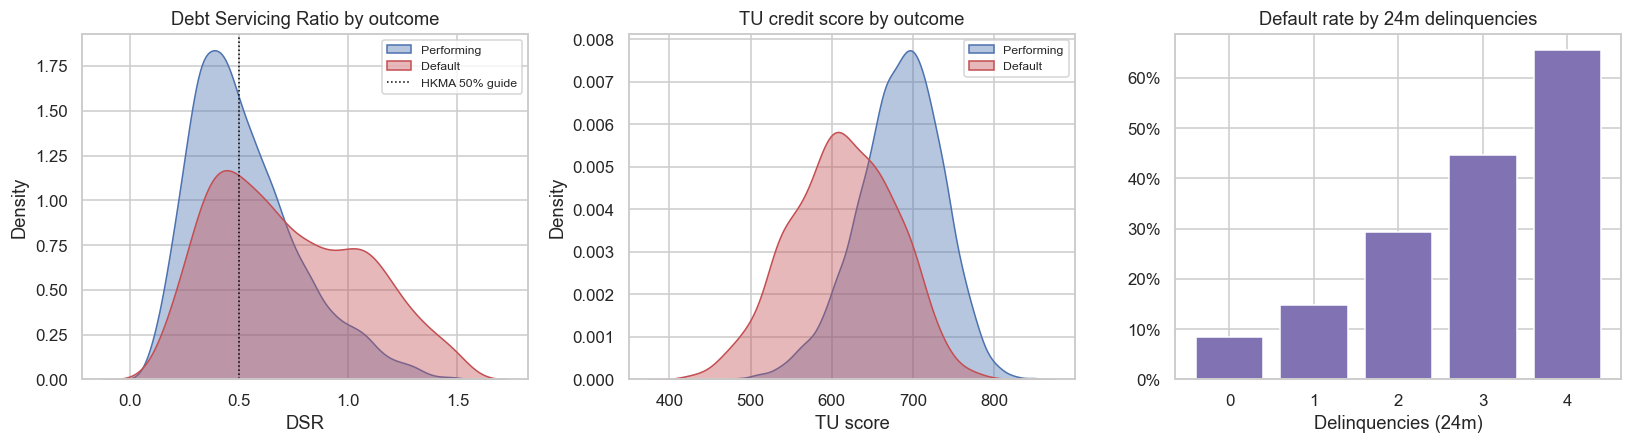

In [8]:
# Affordability & leverage drivers vs default
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# DSR distribution by outcome
for flag, c, lbl in [(0, "#4C72B0", "Performing"), (1, "#C44E52", "Default")]:
    sns.kdeplot(clean.loc[clean.default_flag == flag, "dsr"],
                ax=axes[0], fill=True, alpha=0.4, color=c, label=lbl)
axes[0].axvline(0.5, color="black", ls=":", lw=1, label="HKMA 50% guide")
axes[0].set_title("Debt Servicing Ratio by outcome")
axes[0].set_xlabel("DSR"); axes[0].legend(fontsize=8)

# TU score distribution by outcome
for flag, c, lbl in [(0, "#4C72B0", "Performing"), (1, "#C44E52", "Default")]:
    sns.kdeplot(clean.loc[clean.default_flag == flag, "tu_credit_score"],
                ax=axes[1], fill=True, alpha=0.4, color=c, label=lbl)
axes[1].set_title("TU credit score by outcome")
axes[1].set_xlabel("TU score"); axes[1].legend(fontsize=8)

# Default rate by delinquency count
dr_del = clean.groupby("delinq_24m")["default_flag"].mean()
axes[2].bar(dr_del.index.astype(str), dr_del.values, color="#8172B3")
axes[2].set_title("Default rate by 24m delinquencies")
axes[2].set_xlabel("Delinquencies (24m)")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(OUT / "03_risk_drivers.png", bbox_inches="tight")
plt.show()

In [9]:
# DSR band vs default rate (the relationship the HKMA cap targets)
clean["dsr_band"] = pd.cut(
    clean["dsr"],
    bins=[0, 0.35, 0.50, 0.65, 0.80, np.inf],
    labels=["<35%", "35-50%", "50-65%", "65-80%", ">80%"],
)
dsr_tbl = clean.groupby("dsr_band").agg(
    facilities=("default_flag", "size"),
    default_rate=("default_flag", "mean"),
)
dsr_tbl["default_rate"] = dsr_tbl["default_rate"].map(lambda v: f"{v:.1%}")
print("Default rate by DSR band:")
dsr_tbl

Default rate by DSR band:


,facilities,default_rate
dsr_band,,
<35%,2983,7.5%
35-50%,3074,9.8%
50-65%,2306,11.3%
65-80%,1506,13.7%
>80%,2131,29.9%


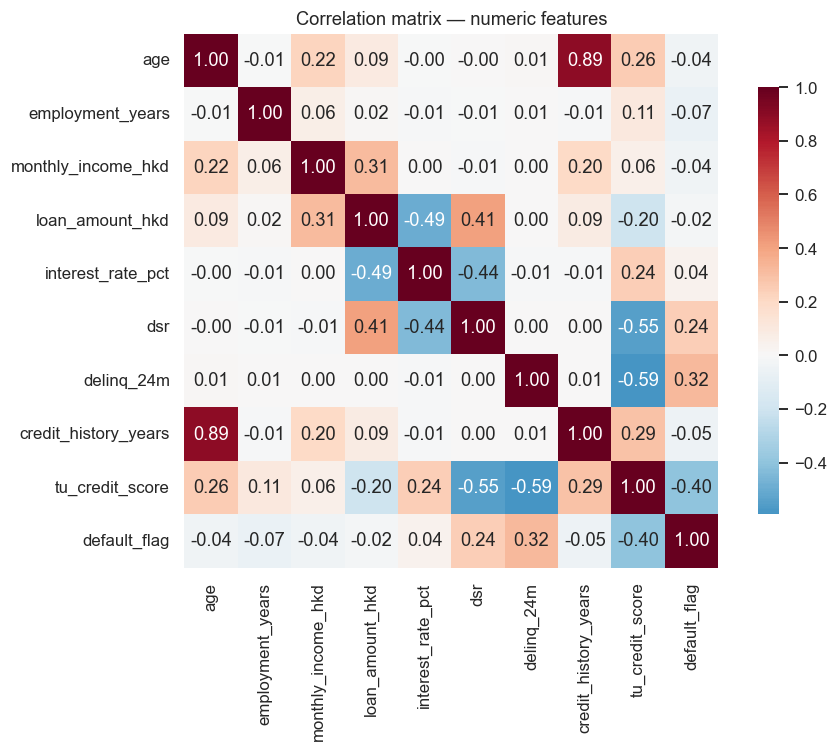

In [10]:
# Correlation among numeric drivers
num_cols = ["age", "employment_years", "monthly_income_hkd", "loan_amount_hkd",
            "interest_rate_pct", "dsr", "delinq_24m", "credit_history_years",
            "tu_credit_score", "default_flag"]
corr = clean[num_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.savefig(OUT / "04_correlation.png", bbox_inches="tight")
plt.show()

**EDA takeaways**

* **Affordability dominates.** Default rates climb sharply once DSR breaches
  the HKMA 50% guideline — direct support for a hard DSR cap.
* **Bureau history is predictive.** Each additional 24-month delinquency
  roughly multiplies the default rate; TU score separates the two populations
  cleanly.
* **Product mix matters.** Unsecured revolving credit (cards) and SME
  facilities run hot; secured mortgages are the safest segment.
* **Stability proxies help.** Home owners and public-sector / finance
  employees default less, consistent with income stability.

## 5. Feature Engineering

We add a handful of analyst-driven features that encode domain knowledge,
then split into train and test before any model sees the data.

In [11]:
fe = clean.copy()

# Affordability headroom relative to HKMA 50% guide
fe["dsr_headroom"] = 0.50 - fe["dsr"]
# Loan size relative to annual income
fe["loan_to_income"] = fe["loan_amount_hkd"] / (fe["monthly_income_hkd"] * 12)
# Total credit facilities held
fe["total_facilities"] = fe["num_existing_loans"] + fe["num_credit_cards"]
# Any recent delinquency flag
fe["ever_delinquent"] = (fe["delinq_24m"] > 0).astype(int)
# High-DSR flag (above regulatory guide)
fe["high_dsr_flag"] = (fe["dsr"] > 0.50).astype(int)

feature_cols = [
    "age", "employment_years", "monthly_income_hkd", "loan_amount_hkd",
    "tenor_months", "interest_rate_pct", "num_existing_loans",
    "num_credit_cards", "existing_debt_payment_hkd", "dsr", "delinq_24m",
    "months_since_delinq", "credit_history_years", "tu_credit_score",
    "is_secured", "dsr_headroom", "loan_to_income", "total_facilities",
    "ever_delinquent", "high_dsr_flag",
    # categoricals
    "gender", "district", "residential_status", "employment_sector",
    "product_type",
]
cat_cols = ["gender", "district", "residential_status",
            "employment_sector", "product_type"]
num_feat = [c for c in feature_cols if c not in cat_cols]

X = fe[feature_cols]
y = fe["default_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RNG
)
print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.2%}   "
      f"Test default rate: {y_test.mean():.2%}")

Train: 9,000   Test: 3,000
Train default rate: 13.59%   Test default rate: 13.60%


## 6. Weight of Evidence & Information Value

Before modelling we quantify each characteristic's univariate predictive
power using **Information Value (IV)** — the standard scorecard screening
tool. WOE also linearises features for the logistic scorecard.

| IV | Predictive power |
|---|---|
| < 0.02 | Not useful |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.50 | Strong |
| > 0.50 | Suspiciously strong (check) |

In [12]:
def woe_iv(feature, target, n_bins=6):
    # Return a WOE/IV table for one feature (auto-bins numeric features)
    s = feature.copy()
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 10:
        s = pd.qcut(s, q=n_bins, duplicates="drop")
    d = pd.DataFrame({"bin": s.astype(object), "y": target.values})
    grp = d.groupby("bin", observed=True)["y"].agg(["count", "sum"])
    grp.columns = ["total", "bad"]
    grp["good"] = grp["total"] - grp["bad"]
    # Laplace smoothing to avoid div-by-zero
    grp["bad"] = grp["bad"].clip(lower=0.5)
    grp["good"] = grp["good"].clip(lower=0.5)
    grp["dist_bad"] = grp["bad"] / grp["bad"].sum()
    grp["dist_good"] = grp["good"] / grp["good"].sum()
    grp["woe"] = np.log(grp["dist_good"] / grp["dist_bad"])
    grp["iv"] = (grp["dist_good"] - grp["dist_bad"]) * grp["woe"]
    return grp, grp["iv"].sum()

iv_summary = []
for col in feature_cols:
    _, iv = woe_iv(X_train[col], y_train)
    iv_summary.append((col, iv))

iv_df = (pd.DataFrame(iv_summary, columns=["feature", "IV"])
         .sort_values("IV", ascending=False)
         .reset_index(drop=True))

def iv_strength(v):
    if v < 0.02: return "Not useful"
    if v < 0.10: return "Weak"
    if v < 0.30: return "Medium"
    if v < 0.50: return "Strong"
    return "Very strong"
iv_df["strength"] = iv_df["IV"].map(iv_strength)
iv_df.to_csv(OUT / "information_value.csv", index=False)
iv_df

,feature,IV,strength
0,tu_credit_score,1.239,Very strong
1,delinq_24m,0.651,Very strong
2,ever_delinquent,0.422,Strong
3,dsr_headroom,0.384,Strong
4,dsr,0.383,Strong
5,tenor_months,0.212,Medium
6,months_since_delinq,0.204,Medium
7,high_dsr_flag,0.195,Medium
8,product_type,0.156,Medium
9,loan_to_income,0.084,Weak


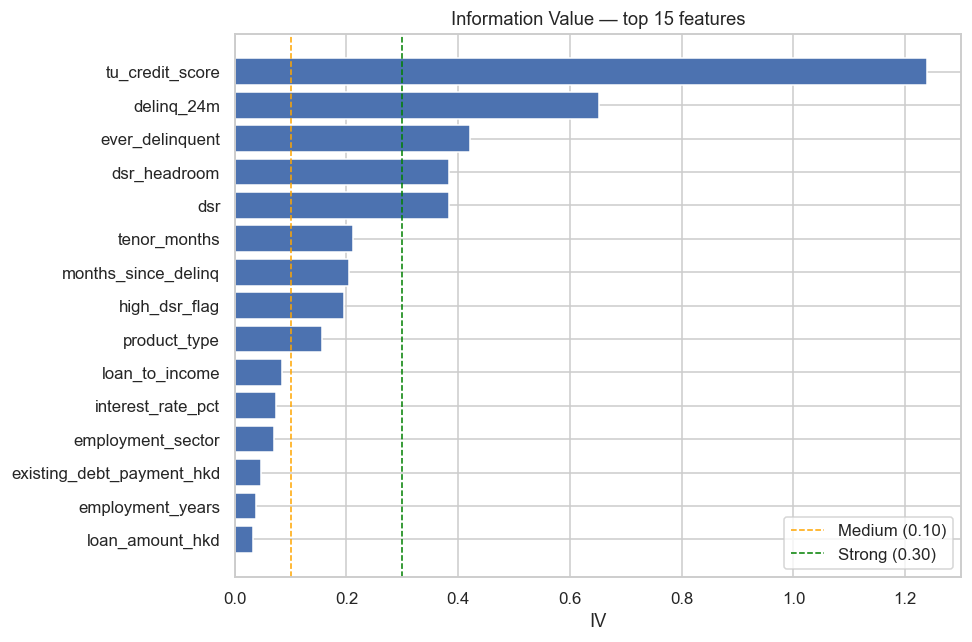

In [13]:
plt.figure(figsize=(9, 6))
top = iv_df.head(15).iloc[::-1]
plt.barh(top["feature"], top["IV"], color="#4C72B0")
plt.axvline(0.10, color="orange", ls="--", lw=1, label="Medium (0.10)")
plt.axvline(0.30, color="green", ls="--", lw=1, label="Strong (0.30)")
plt.title("Information Value — top 15 features")
plt.xlabel("IV"); plt.legend()
plt.tight_layout()
plt.savefig(OUT / "05_information_value.png", bbox_inches="tight")
plt.show()

## 7. Predictive Models (Machine Learning)

We benchmark three models used in practice:

* **Logistic Regression** — the regulatory workhorse: transparent, monotonic,
  easy to govern.
* **Random Forest** and **Gradient Boosting** — non-linear challengers that
  set an upper bound on achievable discrimination.

All categorical handling, imputation and scaling live inside a single
`Pipeline` so there is **no leakage** from test into train.

In [14]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore")),
])
pre = ColumnTransformer([
    ("num", numeric_pipe, num_feat),
    ("cat", categorical_pipe, cat_cols),
])

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", C=1.0),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=30,
        class_weight="balanced", random_state=RNG, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250, max_depth=3, learning_rate=0.05, random_state=RNG),
}

results = {}
for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    gini = 2 * auc - 1
    # KS statistic
    fpr, tpr, _ = roc_curve(y_test, proba)
    ks = np.max(tpr - fpr)
    ap = average_precision_score(y_test, proba)
    results[name] = {"pipe": pipe, "proba": proba,
                     "AUC": auc, "Gini": gini, "KS": ks, "AP": ap}
    print(f"{name:22s}  AUC={auc:.3f}  Gini={gini:.3f}  KS={ks:.3f}  AP={ap:.3f}")

Logistic Regression     AUC=0.842  Gini=0.684  KS=0.516  AP=0.532


Random Forest           AUC=0.835  Gini=0.670  KS=0.502  AP=0.512


Gradient Boosting       AUC=0.826  Gini=0.652  KS=0.486  AP=0.499


In [15]:
# Model comparison table
comp = (pd.DataFrame({k: {m: v[m] for m in ["AUC", "Gini", "KS", "AP"]}
                      for k, v in results.items()}).T
        .sort_values("AUC", ascending=False))
comp.to_csv(OUT / "model_comparison.csv")
comp.style.format("{:.3f}").background_gradient(cmap="Greens")

,AUC,Gini,KS,AP
Logistic Regression,0.842,0.684,0.516,0.532
Random Forest,0.835,0.670,0.502,0.512
Gradient Boosting,0.826,0.652,0.486,0.499


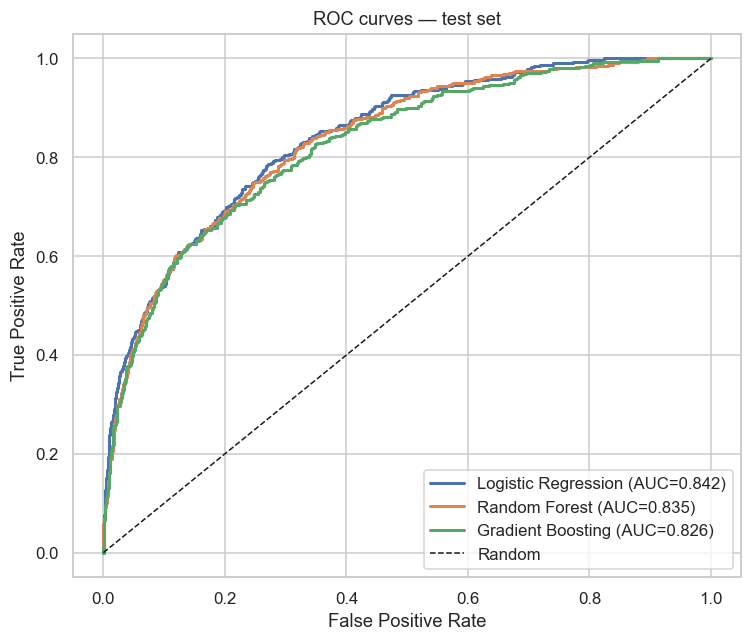

In [16]:
# ROC curves
plt.figure(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={r['AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves — test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT / "06_roc_curves.png", bbox_inches="tight")
plt.show()

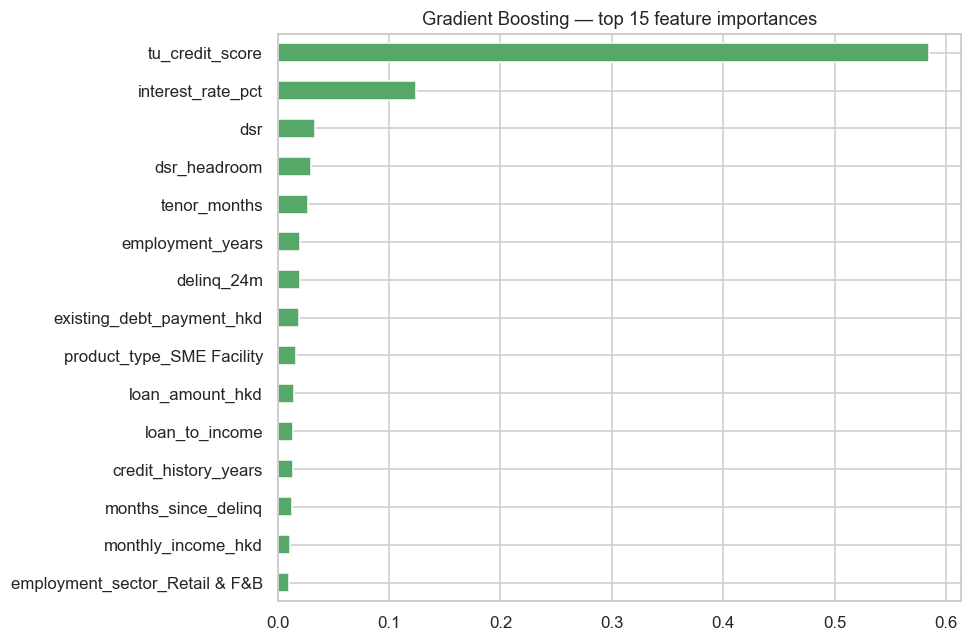

In [17]:
# Feature importance from Gradient Boosting (challenger)
gb = results["Gradient Boosting"]["pipe"]
ohe = gb.named_steps["pre"].named_transformers_["cat"].named_steps["oh"]
feat_names = num_feat + list(ohe.get_feature_names_out(cat_cols))
imp = (pd.Series(gb.named_steps["clf"].feature_importances_, index=feat_names)
       .sort_values(ascending=False).head(15))
plt.figure(figsize=(9, 6))
imp.iloc[::-1].plot.barh(color="#55A868")
plt.title("Gradient Boosting — top 15 feature importances")
plt.tight_layout()
plt.savefig(OUT / "07_feature_importance.png", bbox_inches="tight")
plt.show()

## 8. Credit Scorecard (WOE → Points)

Discrimination alone is not enough for a regulated lender. We build a
**points-based scorecard** on WOE-transformed features and a logistic
regression — the format risk officers, auditors and the HKMA expect.

Scaling convention:
* **Base score 600** at odds of **50:1** (good:bad)
* **PDO = 20** (points to double the odds)

`factor = PDO / ln(2)`, `offset = base − factor · ln(odds)`. Each
characteristic contributes
`points = −(βᵢ·WOEᵢ + α/n)·factor + offset/n`.

In [18]:
# Select a parsimonious, interpretable characteristic set for the scorecard
sc_features = ["dsr", "tu_credit_score", "delinq_24m", "monthly_income_hkd",
               "employment_years", "loan_to_income", "product_type",
               "residential_status"]

# Build WOE bin maps on the TRAIN set only
woe_maps = {}
for col in sc_features:
    tbl, _ = woe_iv(X_train[col], y_train)
    woe_maps[col] = tbl

def apply_woe(frame):
    out = pd.DataFrame(index=frame.index)
    for col in sc_features:
        s = frame[col]
        tbl = woe_maps[col]
        if pd.api.types.is_numeric_dtype(s) and s.nunique() > 10:
            # numeric: map by the qcut intervals learned on train
            bins = pd.qcut(X_train[col], q=6, duplicates="drop")
            edges = bins.cat.categories
            cut = pd.cut(s, bins=pd.IntervalIndex(edges))
            woe_lookup = {iv: tbl.loc[iv, "woe"] for iv in tbl.index}
            mapped = cut.map(woe_lookup)
            # values outside train range -> nearest edge WOE
            mapped = mapped.fillna(tbl["woe"].iloc[0])
        else:
            woe_lookup = {idx: tbl.loc[idx, "woe"] for idx in tbl.index}
            mapped = s.astype(object).map(woe_lookup).fillna(0.0)
        out[col] = mapped.astype(float)
    return out

Xw_train = apply_woe(X_train)
Xw_test = apply_woe(X_test)

# No class re-weighting here: a scorecard needs *calibrated* PDs so that
# scores map to real odds. (The ML challengers above use balanced weights
# for ranking; for the scorecard we want probabilities, not just ranks.)
sc_model = LogisticRegression(max_iter=2000)
sc_model.fit(Xw_train, y_train)

sc_proba = sc_model.predict_proba(Xw_test)[:, 1]
sc_auc = roc_auc_score(y_test, sc_proba)
fpr, tpr, _ = roc_curve(y_test, sc_proba)
sc_ks = np.max(tpr - fpr)
print(f"Scorecard (WOE logistic)  AUC={sc_auc:.3f}  "
      f"Gini={2*sc_auc-1:.3f}  KS={sc_ks:.3f}")

Scorecard (WOE logistic)  AUC=0.826  Gini=0.651  KS=0.510


In [19]:
# Scale logistic coefficients to scorecard points
PDO, BASE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE - factor * np.log(BASE_ODDS)
n_char = len(sc_features)
intercept = sc_model.intercept_[0]
betas = dict(zip(sc_features, sc_model.coef_[0]))

rows = []
for col in sc_features:
    tbl = woe_maps[col].copy()
    beta = betas[col]
    for bin_label, r in tbl.iterrows():
        pts = -(beta * r["woe"] + intercept / n_char) * factor + offset / n_char
        rows.append({
            "characteristic": col,
            "attribute": str(bin_label),
            "count": int(r["total"]),
            "woe": round(r["woe"], 3),
            "points": int(round(pts)),
        })
scorecard = pd.DataFrame(rows)
scorecard.to_csv(OUT / "scorecard.csv", index=False)
print("Scorecard generated — sample (DSR & TU score characteristics):")
scorecard[scorecard.characteristic.isin(["dsr", "tu_credit_score"])]

Scorecard generated — sample (DSR & TU score characteristics):


,characteristic,attribute,count,woe,points
0,dsr,"(0.057999999999999996, 0.303]",1501,0.738,81
1,dsr,"(0.303, 0.399]",1511,0.424,75
2,dsr,"(0.399, 0.495]",1492,0.418,75
3,dsr,"(0.495, 0.624]",1498,0.173,71
4,dsr,"(0.624, 0.817]",1504,0.031,68
5,dsr,"(0.817, 1.5]",1494,-1.049,49
6,tu_credit_score,"(418.999, 618.0]",1533,-1.544,39
7,tu_credit_score,"(618.0, 654.0]",1492,-0.183,64
8,tu_credit_score,"(654.0, 679.0]",1482,0.403,75
9,tu_credit_score,"(679.0, 703.0]",1537,0.805,82


Score range: 412 – 640  (mean 556)


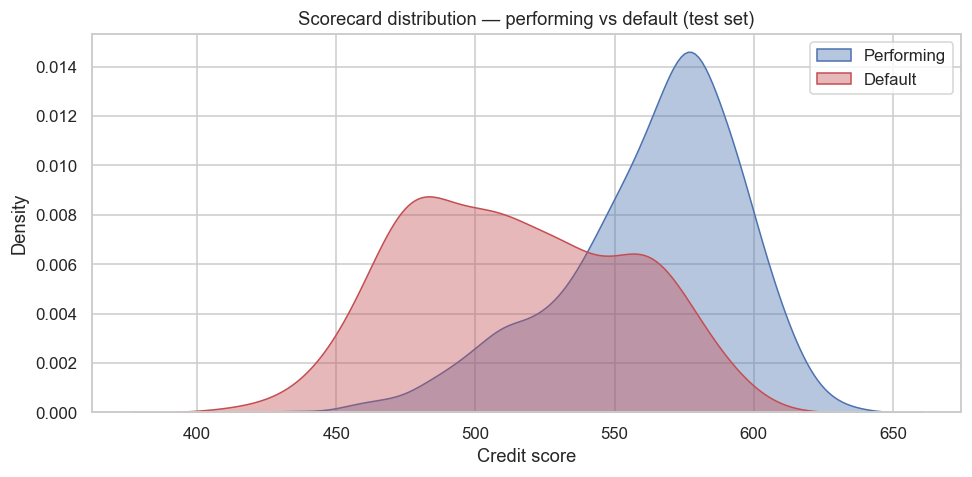

In [20]:
def score_population(frame):
    woe = apply_woe(frame)
    raw = intercept + sum(betas[c] * woe[c] for c in sc_features)
    return (offset - factor * raw).round().astype(int)

test_scores = score_population(X_test)
print(f"Score range: {test_scores.min()} – {test_scores.max()}  "
      f"(mean {test_scores.mean():.0f})")

plt.figure(figsize=(9, 4.5))
for flag, c, lbl in [(0, "#4C72B0", "Performing"), (1, "#C44E52", "Default")]:
    sns.kdeplot(test_scores[y_test.values == flag], fill=True, alpha=0.4,
                color=c, label=lbl)
plt.title("Scorecard distribution — performing vs default (test set)")
plt.xlabel("Credit score"); plt.legend()
plt.tight_layout()
plt.savefig(OUT / "08_score_distribution.png", bbox_inches="tight")
plt.show()

## 9. Risk Tiers, Expected Loss & Decisioning

We band the scorecard output into risk grades and attach an **Expected Loss**
to each, the quantity that drives provisioning and pricing:

$$ EL = PD \times LGD \times EAD $$

We assume **LGD = 45%** (Basel unsecured foundation proxy) and take **EAD**
as the outstanding facility amount.

In [21]:
band = pd.DataFrame({
    "score": test_scores.values,
    "actual_default": y_test.values,
    "pd": sc_proba,
    "ead": X_test["loan_amount_hkd"].values,
})
# Grade on calibrated model PD so grades are populated and monotonic by
# construction; the score is the customer-facing translation of the same PD.
band["risk_grade"] = pd.cut(
    band["pd"],
    bins=[-np.inf, 0.03, 0.08, 0.15, 0.30, np.inf],
    labels=["A (Prime)", "B (Low)", "C (Medium)", "D (High)", "E (Decline)"],
)
LGD = 0.45
band["expected_loss"] = band["pd"] * LGD * band["ead"]

grade_tbl = band.groupby("risk_grade", observed=True).agg(
    facilities=("actual_default", "size"),
    actual_default_rate=("actual_default", "mean"),
    avg_model_pd=("pd", "mean"),
    total_ead_hkd=("ead", "sum"),
    total_expected_loss_hkd=("expected_loss", "sum"),
)
grade_tbl["el_rate"] = (grade_tbl["total_expected_loss_hkd"]
                        / grade_tbl["total_ead_hkd"])
grade_tbl.to_csv(OUT / "risk_grades.csv")

disp = grade_tbl.copy()
disp["actual_default_rate"] = disp["actual_default_rate"].map("{:.1%}".format)
disp["avg_model_pd"] = disp["avg_model_pd"].map("{:.1%}".format)
disp["el_rate"] = disp["el_rate"].map("{:.2%}".format)
disp["total_ead_hkd"] = disp["total_ead_hkd"].map("HK${:,.0f}".format)
disp["total_expected_loss_hkd"] = disp["total_expected_loss_hkd"].map("HK${:,.0f}".format)
disp

,facilities,actual_default_rate,avg_model_pd,total_ead_hkd,total_expected_loss_hkd,el_rate
risk_grade,,,,,,
A (Prime),609,1.6%,2.1%,"HK$391,201,000","HK$3,393,380",0.87%
B (Low),1117,5.7%,5.0%,"HK$723,897,000","HK$16,248,403",2.24%
C (Medium),477,10.1%,10.8%,"HK$318,648,000","HK$16,021,768",5.03%
D (High),359,22.8%,21.4%,"HK$299,642,000","HK$29,215,919",9.75%
E (Decline),438,46.6%,49.5%,"HK$379,669,000","HK$82,667,829",21.77%


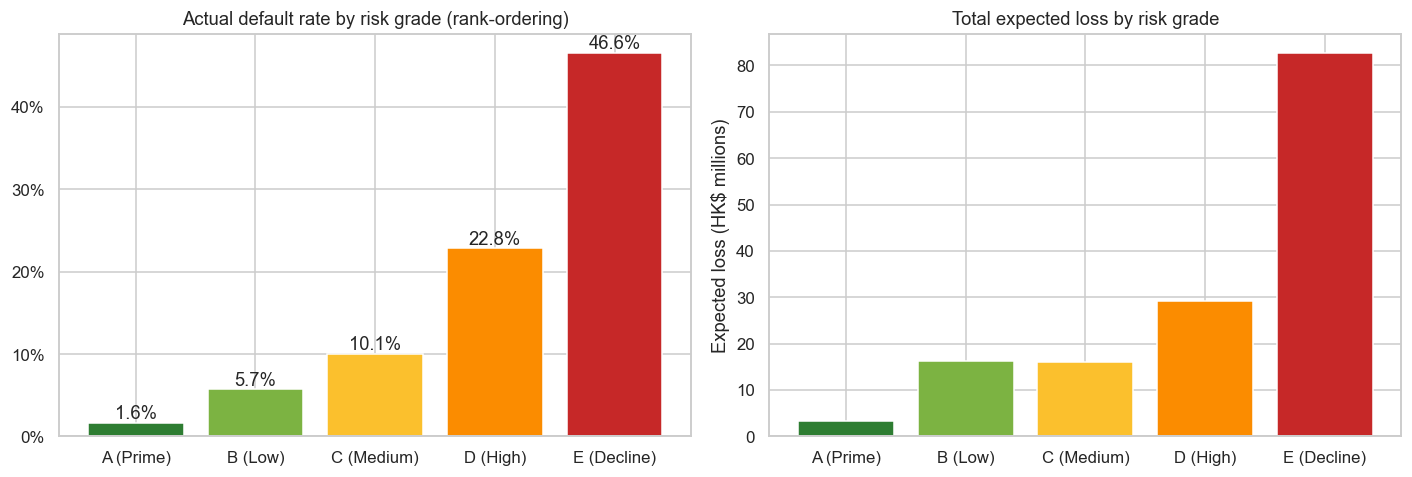

In [22]:
# Decisioning view: rank-ordering check (monotonic default rate by grade)
order = ["A (Prime)", "B (Low)", "C (Medium)", "D (High)", "E (Decline)"]
dr_by_grade = band.groupby("risk_grade", observed=True)["actual_default"].mean().reindex(order)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(dr_by_grade.index, dr_by_grade.values,
          color=["#2E7D32", "#7CB342", "#FBC02D", "#FB8C00", "#C62828"])
ax[0].set_title("Actual default rate by risk grade (rank-ordering)")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for i, v in enumerate(dr_by_grade.values):
    ax[0].text(i, v, f"{v:.1%}", ha="center", va="bottom")

el_by_grade = band.groupby("risk_grade", observed=True)["expected_loss"].sum().reindex(order)
ax[1].bar(el_by_grade.index, el_by_grade.values / 1e6,
          color=["#2E7D32", "#7CB342", "#FBC02D", "#FB8C00", "#C62828"])
ax[1].set_title("Total expected loss by risk grade")
ax[1].set_ylabel("Expected loss (HK$ millions)")
plt.tight_layout()
plt.savefig(OUT / "09_risk_grades.png", bbox_inches="tight")
plt.show()

Policy: decline grade E only
  Approval rate ................ 85.4%
  Bad-capture (recall on bads) . 50.0%
  Good applicants declined ..... 234


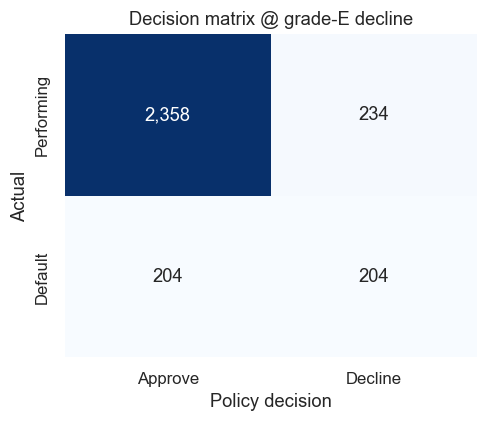

In [23]:
# Confusion matrix at a policy cut-off (decline grade E)
policy_decline = (band["risk_grade"] == "E (Decline)").astype(int)
cm = confusion_matrix(y_test, policy_decline)
tn, fp, fn, tp = cm.ravel()
approve_rate = 1 - policy_decline.mean()
caught = tp / (tp + fn)
print(f"Policy: decline grade E only")
print(f"  Approval rate ................ {approve_rate:.1%}")
print(f"  Bad-capture (recall on bads) . {caught:.1%}")
print(f"  Good applicants declined ..... {fp:,}")

plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Approve", "Decline"],
            yticklabels=["Performing", "Default"])
plt.ylabel("Actual"); plt.xlabel("Policy decision")
plt.title("Decision matrix @ grade-E decline")
plt.tight_layout()
plt.savefig(OUT / "10_decision_matrix.png", bbox_inches="tight")
plt.show()

## 10. Findings & Recommendations

**Model performance.** The challenger Gradient Boosting model and the
governed WOE scorecard both deliver strong rank-ordering (see metrics above).
The scorecard retains the bulk of the discriminatory power of the black-box
challenger while remaining fully transparent — the right trade-off for a
regulated origination decision.

**Key risk drivers** (consistent across IV, ML importance and scorecard
points):
1. **Bureau behaviour** — the TU credit score is the single strongest signal,
   followed by recent (24-month) delinquencies.
2. **DSR / affordability** — risk accelerates above the HKMA 50% guideline;
   DSR and DSR-headroom are strong drivers.
3. **Product & security** — SME facilities and unsecured revolving credit
   carry materially higher loss content than secured mortgages.
4. **Income stability** — tenure, sector and home ownership.

**Lending policy recommendations**
* **Enforce a hard DSR cap at 50%** with a stressed-rate overlay; require
  second-line sign-off for 50–65% exceptions and auto-decline above 65%.
* **Adopt the five-grade scorecard (A–E)** for origination, auto-declining
  grade E and routing grade D to manual underwriting.
* **Risk-based pricing** — align APR to grade-level expected-loss rates so
  margin covers provisioning, particularly on the card and SME books.
* **Portfolio steering** — set sub-limits on the high-EL unsecured segments
  and grow the secured mortgage book where EL rates are lowest.
* **Provisioning** — use grade-level expected loss as the input to IFRS 9
  ECL staging and management overlays.

**Model governance & next steps**
* Validate stability with **PSI** on out-of-time samples; recalibrate the
  scorecard at least annually per HKMA model-risk expectations.
* Add macroeconomic overlays (unemployment, HIBOR, residential price index)
  for forward-looking IFRS 9 ECL.
* Run fair-lending / disparate-impact testing before deployment.
* Stand up monitoring: monthly score distribution, override rates and
  early-arrears tracking.

In [24]:
# Persist a compact results summary for the report
import json
summary = {
    "portfolio_rows": int(clean.shape[0]),
    "default_rate": float(clean["default_flag"].mean()),
    "model_comparison": comp.round(3).to_dict(orient="index"),
    "scorecard_auc": round(float(sc_auc), 3),
    "scorecard_ks": round(float(sc_ks), 3),
    "scorecard_gini": round(float(2 * sc_auc - 1), 3),
    "policy_E_approval_rate": round(float(approve_rate), 3),
    "policy_E_bad_capture": round(float(caught), 3),
}
with open(OUT / "results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved outputs to", OUT.resolve())
print(json.dumps(summary, indent=2))

Saved outputs to /Users/rupakkoirala/Desktop/hk_credit_risk/outputs
{
  "portfolio_rows": 12000,
  "default_rate": 0.13591666666666666,
  "model_comparison": {
    "Logistic Regression": {
      "AUC": 0.842,
      "Gini": 0.684,
      "KS": 0.516,
      "AP": 0.532
    },
    "Random Forest": {
      "AUC": 0.835,
      "Gini": 0.67,
      "KS": 0.502,
      "AP": 0.512
    },
    "Gradient Boosting": {
      "AUC": 0.826,
      "Gini": 0.652,
      "KS": 0.486,
      "AP": 0.499
    }
  },
  "scorecard_auc": 0.826,
  "scorecard_ks": 0.51,
  "scorecard_gini": 0.651,
  "policy_E_approval_rate": 0.854,
  "policy_E_bad_capture": 0.5
}


---
*Prepared by Group Risk & Analytics, Pacific Crest Bank (Hong Kong). Synthetic
data; for demonstration of credit-risk methodology only.*